In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.xls to data.xls


In [3]:
df = pd.read_csv('data.xls')

In [4]:
df.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text
0,University_1,73.0,2.5,2024-10-14,2.0,1. зміст навчання і предмети не відповідають с...
1,University_1,73.0,2.5,2024-09-23,4.0,"Хороший преподавательский состав, размеренное ..."
2,University_1,73.0,2.5,2023-02-02,1.0,"Три года обучения дистанционно, хотя в других ..."
3,University_1,73.0,2.5,2023-01-23,1.0,"Працюють лише старі як перед смертю, або ті ко..."
4,University_1,73.0,2.5,2022-09-16,1.0,"При поступлении отвратительное отношение, кажд..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6299 entries, 0 to 6298
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   University Name  6299 non-null   object 
 1   Reviews Count    6298 non-null   float64
 2   Average Rating   6298 non-null   object 
 3   Review Date      6298 non-null   object 
 4   Review Rating    6298 non-null   float64
 5   Review Text      6297 non-null   object 
dtypes: float64(2), object(4)
memory usage: 295.4+ KB


#Preprocessing
- The collected reviews from all sources were combined into a single DataFrame (This step was performed outside of this notebook to preserve the anonymity of the universities).

- Entries without review text were removed.

- Since the data came from different platforms, discrepancies appeared in:

university names,

date formats,

number of reviews,

average ratings.

- University names were standardized (e.g., consistent abbreviations, removal of extra spaces/symbols)((This step was performed outside of this notebook to preserve the anonymity of the universities)).

- Reviews from universities with fewer than 100 entries were excluded from the analysis to ensure statistical significance.

- The values in the "Reviews Count" column were updated based on data from all sources.

- The average rating was calculated as the arithmetic mean of the star ratings for each university.

- New columns Timestamp and Year were added to facilitate date-based analysis.


In [6]:
# Check if there are any missing values in the DataFrame
df[df.isnull().any(axis=1)]


,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text
228,University_6,137.0,2.9,2017-10-03,5.0,NaN
872,University_17,NaN,NaN,NaN,NaN,NaN


In [7]:
# Remove all rows where the review text is missing
df.drop(index=[228, 872], inplace=True)

In [8]:
df[df.isnull().any(axis=1)]

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text


In [9]:
# Count the number of reviews for each university
counts = df['University Name'].value_counts()
counts

,count
University Name,
University_1,716
University_2,710
University_3,670
University_4,466
University_5,437
University_6,391
University_7,348
University_8,325
University_9,263


In [10]:
#Get a list of universities with 100 or more reviews
universities_to_keep = counts[counts >= 100].index

In [11]:
# Filter the DataFrame to keep universities with 100 or more reviews
df_filtered = df[df['University Name'].isin(universities_to_keep)].reset_index(drop=True)

In [12]:
df_filtered

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text
0,University_1,73.0,2.5,2024-10-14,2.0,1. зміст навчання і предмети не відповідають с...
1,University_1,73.0,2.5,2024-09-23,4.0,"Хороший преподавательский состав, размеренное ..."
2,University_1,73.0,2.5,2023-02-02,1.0,"Три года обучения дистанционно, хотя в других ..."
3,University_1,73.0,2.5,2023-01-23,1.0,"Працюють лише старі як перед смертю, або ті ко..."
4,University_1,73.0,2.5,2022-09-16,1.0,"При поступлении отвратительное отношение, кажд..."
...,...,...,...,...,...,...
6270,University_1,643.0,2.9,05.04.2010,4.0,"Учусь пятый год. Есть и минусы, но плюсов боль..."
6271,University_1,643.0,2.9,03.04.2010,5.0,Я его очень люблю
6272,University_1,643.0,2.9,12.02.2010,1.0,"учусь 4й год,с первого курса обещают дать акре..."
6273,University_1,643.0,2.9,02.09.2009,4.0,Учился в этом ВУЗе на факультете компьютерных ...


In [13]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   University Name  6275 non-null   object 
 1   Reviews Count    6275 non-null   float64
 2   Average Rating   6275 non-null   object 
 3   Review Date      6275 non-null   object 
 4   Review Rating    6275 non-null   float64
 5   Review Text      6275 non-null   object 
dtypes: float64(2), object(4)
memory usage: 294.3+ KB


In [14]:
# Convert the 'Reviews Count' column to integer type, since review counts should be whole numbers
df_filtered['Reviews Count'] = df_filtered['Reviews Count'].astype(int)

In [15]:
# Convert the 'Average Rating' column from object to numeric, coercing any invalid values to NaN
df_filtered['Average Rating'] = pd.to_numeric(df_filtered['Average Rating'], errors='coerce')

In [16]:
# Calculate the average review rating for each university
avg_scores = df_filtered.groupby('University Name')['Review Rating'].mean().reset_index()
avg_scores = avg_scores.sort_values(by='Review Rating', ascending=False).reset_index(drop=True)
avg_scores

,University Name,Review Rating
0,University_3,4.098507
1,University_13,4.065217
2,University_21,3.931373
3,University_20,3.796117
4,University_15,3.715152
5,University_8,3.553846
6,University_11,3.512821
7,University_18,3.495935
8,University_14,3.471910
9,University_5,3.469108


In [17]:
# Replace the 'Average Rating' column with the average review rating (rounded to 2 decimals) from avg_scores
df_filtered['Average Rating'] = round(df_filtered['University Name'].map(
    avg_scores.set_index('University Name')['Review Rating']), 2)

In [18]:
# Count the number of reviews for each university
summary = df_filtered['University Name'].value_counts().reset_index()
summary.columns = ['University Name', 'Reviews Count']
summary

,University Name,Reviews Count
0,University_1,716
1,University_2,710
2,University_3,670
3,University_4,466
4,University_5,437
5,University_6,391
6,University_7,348
7,University_8,325
8,University_9,263
9,University_10,250


In [19]:
# Replace the 'Reviews Count' column with the actual number of reviews per university
df_filtered['Reviews Count'] = df_filtered['University Name'].map(summary.set_index('University Name')['Reviews Count'])

In [20]:
df_filtered.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text
0,University_1,716,2.97,2024-10-14,2.0,1. зміст навчання і предмети не відповідають с...
1,University_1,716,2.97,2024-09-23,4.0,"Хороший преподавательский состав, размеренное ..."
2,University_1,716,2.97,2023-02-02,1.0,"Три года обучения дистанционно, хотя в других ..."
3,University_1,716,2.97,2023-01-23,1.0,"Працюють лише старі як перед смертю, або ті ко..."
4,University_1,716,2.97,2022-09-16,1.0,"При поступлении отвратительное отношение, кажд..."


In [21]:
# Initialize the column Timestamp
df_filtered['Timestamp'] = pd.NaT

In [22]:
# Mask for dates containing a dot (.)
mask_dot = df_filtered['Review Date'].astype(str).str.contains(r'\.', regex=True, na=False)

In [23]:
# For dates containing dots, convert them to datetime using the format '%d.%m.%Y' and store in 'Timestamp'
df_filtered.loc[mask_dot, 'Timestamp'] = pd.to_datetime(df_filtered.loc[mask_dot, 'Review Date'], format='%d.%m.%Y', errors='coerce')

In [24]:
# Convert review dates in the 'YYYY-MM-DD' format (without dots) to datetime and assign to 'Timestamp'
df_filtered.loc[~mask_dot, 'Timestamp'] = pd.to_datetime(df_filtered.loc[~mask_dot, 'Review Date'], format='%Y-%m-%d', errors='coerce')

In [25]:
# Count the number of non-missing (valid) datetime values in the 'Timestamp' column
df_filtered['Timestamp'].notna().sum()

np.int64(6275)

In [26]:
# Display the number of missing values in each column of the DataFrame
df_filtered.isnull().sum()

,0
University Name,0
Reviews Count,0
Average Rating,0
Review Date,0
Review Rating,0
Review Text,0
Timestamp,0


In [27]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   University Name  6275 non-null   object        
 1   Reviews Count    6275 non-null   int64         
 2   Average Rating   6275 non-null   float64       
 3   Review Date      6275 non-null   object        
 4   Review Rating    6275 non-null   float64       
 5   Review Text      6275 non-null   object        
 6   Timestamp        6275 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 343.3+ KB


Keep the 'Review Date' column as object type to preserve original format,
and use the 'Timestamp' column (converted to datetime) for analysis and time-based operations.

In [28]:
# Extract the year from the 'Timestamp' column and store it in a new column called 'Year'
df_filtered['Year'] = df_filtered.Timestamp.apply(lambda x: x.year)

In [29]:
df_filtered.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year
0,University_1,716,2.97,2024-10-14,2.0,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024
1,University_1,716,2.97,2024-09-23,4.0,"Хороший преподавательский состав, размеренное ...",2024-09-23,2024
2,University_1,716,2.97,2023-02-02,1.0,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023
3,University_1,716,2.97,2023-01-23,1.0,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023
4,University_1,716,2.97,2022-09-16,1.0,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022


#EDA

In [30]:
# Check how reviews are distributed across different years
df_filtered.Year.value_counts().sort_index()

,count
Year,
2009,70
2010,315
2011,449
2012,487
2013,374
2014,285
2015,295
2016,363
2017,548


<Axes: xlabel='Year'>

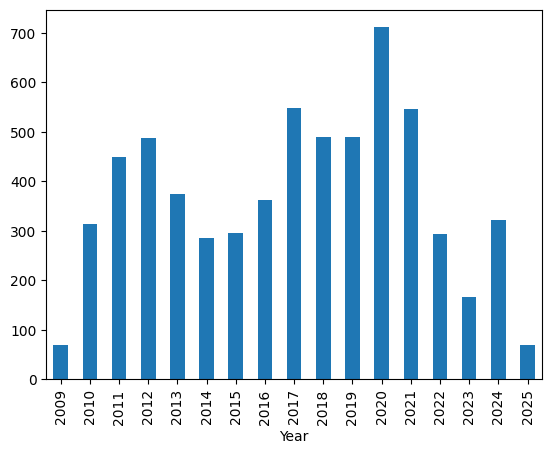

In [31]:
df_filtered.Year.value_counts().sort_index().plot(kind='bar')

In [32]:
# Calculate the frequency of each unique review rating
data = df_filtered['Review Rating']
values, counts = np.unique(data, return_counts=True)

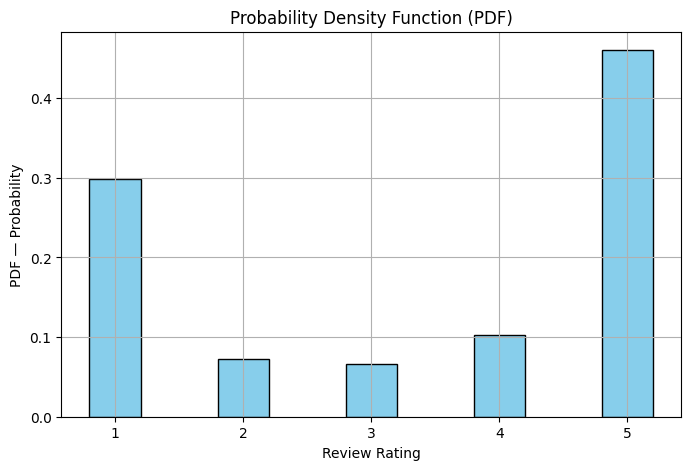

In [33]:
# Plot the Probability Density Function (PDF) of review ratings
pdf = counts / counts.sum()
plt.figure(figsize=(8, 5))
plt.bar(values, pdf, width=0.4, color='skyblue', edgecolor='black')
plt.xlabel('Review Rating')
plt.ylabel('PDF — Probability')
plt.title('Probability Density Function (PDF)')
plt.grid(True)
plt.show()

In [34]:
# Get sorted review ratings
x = df['Review Rating'].dropna().sort_values()

In [35]:
# Create cumulative probabilities for plotting the empirical CDF
y = np.arange(1, len(x) + 1) / len(x)

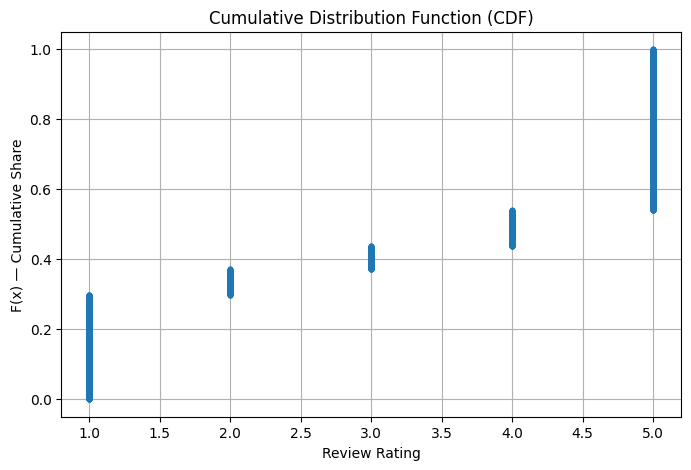

In [36]:
# Plotting the Cumulative Distribution Function (CDF) of review ratings
# This plot demonstrates manual construction of the empirical cumulative distribution function (CDF) using sorted values.

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='.', linestyle='none')
plt.xlabel('Review Rating')
plt.ylabel('F(x) — Cumulative Share')
plt.title('Cumulative Distribution Function (CDF)')
plt.grid(True)
plt.show()

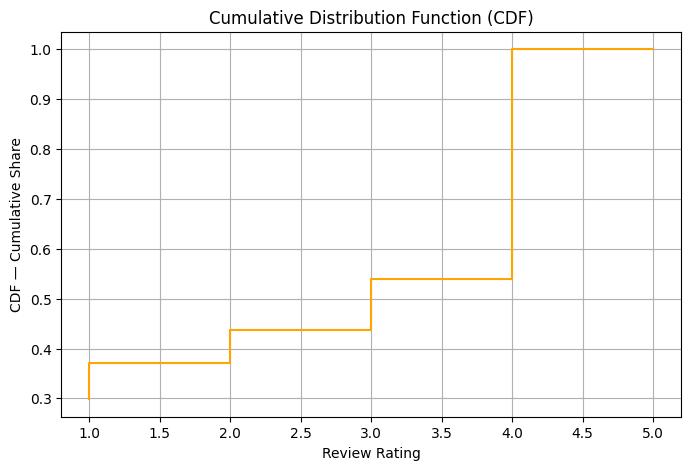

In [37]:
# The second plot builds the CDF by computing the cumulative sum of the probability density function (PDF).
cdf = np.cumsum(pdf)
plt.figure(figsize=(8, 5))
plt.step(values, cdf, color='orange')
plt.xlabel('Review Rating')
plt.ylabel('CDF — Cumulative Share')
plt.title('Cumulative Distribution Function (CDF)')
plt.grid(True)
plt.show()

In [38]:
# Print the percentage of reviews with high, neutral, and low ratings
F_4 = (df['Review Rating'] >= 4).mean()
F_3 = (df['Review Rating'] == 3).mean()
F_2 = (df['Review Rating'] <= 2).mean()
print(f"{F_4:.2f}% of reviews have high ratings")
print(f"{F_3:.2f}% of reviews have neutral ratings")
print(f"{F_2:.2f}% of reviews have low ratings")

0.56% of reviews have high ratings
0.07% of reviews have neutral ratings
0.37% of reviews have low ratings


In [39]:
# Select the top 10 universities with the highest average review ratings
top10 = avg_scores.head(10)
top10

,University Name,Review Rating
0,University_3,4.098507
1,University_13,4.065217
2,University_21,3.931373
3,University_20,3.796117
4,University_15,3.715152
5,University_8,3.553846
6,University_11,3.512821
7,University_18,3.495935
8,University_14,3.471910
9,University_5,3.469108


/tmp/ipython-input-1778905557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


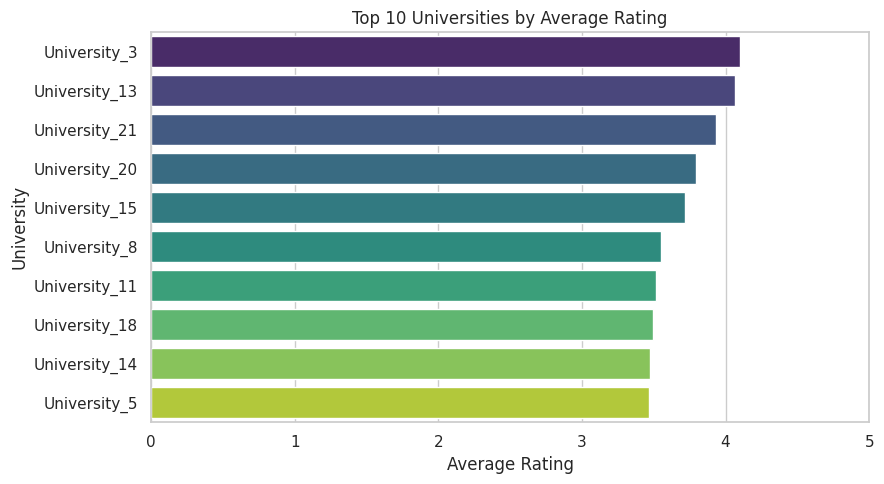

In [50]:
#the top 10 universities with the highest average review ratings
sns.set(style="whitegrid")
plt.figure(figsize=(9,5))
sns.barplot(
    x='Review Rating',
    y='University Name',
    data=top10,
    palette='viridis',
    hue=None,
    dodge=False,
)

plt.title('Top 10 Universities by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('University')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


# Natural Language Processing analysis

In [ ]:
!pip install transformers

In [ ]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline

In [ ]:
# Load the pre-trained multilingual BERT model and tokenizer for sentiment analysis
# The model predicts sentiment scores from 1 to 5 based on input text
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

In [ ]:
# Initialize a sentiment analysis pipeline using the pre-loaded BERT model and tokenizer
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

In [ ]:
import torch
print(torch.cuda.is_available())

In [ ]:
# Initialize a sentiment analysis pipeline using the multilingual BERT model.
# The model runs on GPU (device=0) to speed up inference if available.
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0  # GPU
)

In [ ]:
result = sentiment_pipeline("Я дуже люблю цей університет!")
print(result)

In [ ]:
def get_sentiment_score(text):
    try:
        result = sentiment_pipeline(text[:512])  # truncate text to 512 characters due to model limit
        label = result[0]['label']
        score = int(label[0])  # extract numeric score from label like '4 stars' -> 4
        return score
    except:
        return None  # return None if text is empty or any error occurs

In [ ]:
df_filtered['bert_sentiment'] = df_filtered['Review Text'].astype(str).apply(get_sentiment_score)

In [ ]:
# Define sentiment category based on the BERT sentiment score
def classify_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

# Apply the sentiment classification to create a new column
df['Sentiment_Category_BERT'] = df['bert_sentiment'].apply(classify_sentiment)

In [ ]:
# Save the filtered DataFrame with BERT sentiment to a CSV file
df_filtered.to_csv('data+bert_sentiment.csv', index=False)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data+bert_sentiment.csv to data+bert_sentiment (1).csv


In [ ]:
df = pd.read_csv('data+bert_sentiment.csv')

In [ ]:
df.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT
0,University_1,716,2.97,2024-10-14,2.0,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,2,negative
1,University_1,716,2.97,2024-09-23,4.0,"Хороший преподавательский состав, размеренное ...",2024-09-23,2024,4,positive
2,University_1,716,2.97,2023-02-02,1.0,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,1,negative
3,University_1,716,2.97,2023-01-23,1.0,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,1,negative
4,University_1,716,2.97,2022-09-16,1.0,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,1,negative


Comparison of Text Sentiment and Star Rating

Objective:

- Convert the star rating into a categorical value (negative / neutral / positive).

- Compare it with the BERT-based sentiment (Кат_тональність_BERT).

- Calculate agreement metrics (accuracy, confusion matrix).

In [ ]:
# Encode star rating: up to 2 — negative, 3 — neutral, 4–5 — positive
def star_to_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Star_Sentiment_Category'] = df['Review Rating'].apply(star_to_sentiment)

In [ ]:
# Create a column indicating whether the sentiment categories match
df['Match'] = df['Star_Sentiment_Category'] == df['Sentiment_Category_BERT']

In [ ]:
df.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match
0,University_1,716,2.97,2024-10-14,2.0,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,2,negative,negative,True
1,University_1,716,2.97,2024-09-23,4.0,"Хороший преподавательский состав, размеренное ...",2024-09-23,2024,4,positive,positive,True
2,University_1,716,2.97,2023-02-02,1.0,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,1,negative,negative,True
3,University_1,716,2.97,2023-01-23,1.0,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,1,negative,negative,True
4,University_1,716,2.97,2022-09-16,1.0,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,1,negative,negative,True


In [ ]:
# Proportion of matches
accuracy = df['Match'].mean()
print(f"Accuracy of agreement between star rating and BERT sentiment: {accuracy:.2%}")

Accuracy of agreement between star rating and BERT sentiment: 73.31%


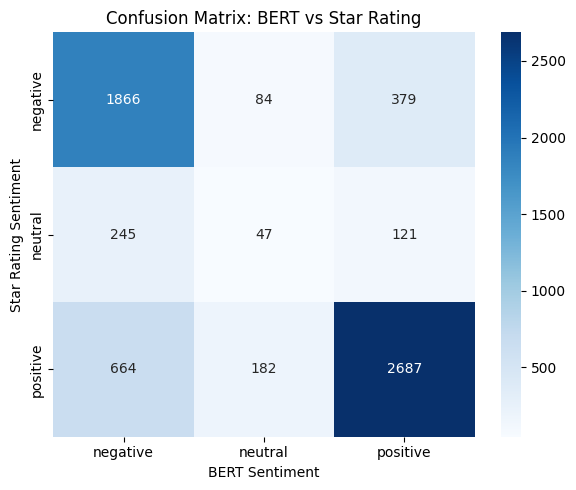

In [ ]:
# Confusion matrix
cm = confusion_matrix(
    df['Star_Sentiment_Category'],
    df['Sentiment_Category_BERT'],
    labels=['negative', 'neutral', 'positive']
)

# Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive'],
    cmap='Blues'
)
plt.xlabel("BERT Sentiment")
plt.ylabel("Star Rating Sentiment")
plt.title("Confusion Matrix: BERT vs Star Rating")
plt.tight_layout()
plt.show()

In [ ]:
# Rows where the sentiment does not match
df_mismatch = df[df['Match'] == False]
df_mismatch

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match
8,University_1,716,2.97,2021-12-09,2.0,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,3,neutral,negative,False
11,University_1,716,2.97,2021-09-29,3.0,"Всем добрый день!Хороший университет,но почему...",2021-09-29,2021,4,positive,neutral,False
12,University_1,716,2.97,2021-08-25,1.0,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,3,neutral,negative,False
16,University_1,716,2.97,2020-06-01,4.0,нормальный университет все прошло хорошо.Кто х...,2020-06-01,2020,1,negative,positive,False
19,University_1,716,2.97,2020-04-07,5.0,"Читая ваши отзывы про другие кафедры, такое чу...",2020-04-07,2020,1,negative,positive,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6257,University_1,716,2.97,08.12.2010,1.0,"Я б відніс цей ""вуз"" до найгірших. Тут працюют...",2010-12-08,2010,5,positive,negative,False
6265,University_1,716,2.97,17.08.2010,5.0,"плохому танцору все мешает!если есть желание, ...",2010-08-17,2010,1,negative,positive,False
6269,University_1,716,2.97,23.05.2010,1.0,авиатехнику сколько платят?подумайте,2010-05-23,2010,3,neutral,negative,False
6273,University_1,716,2.97,02.09.2009,4.0,Учился в этом ВУЗе на факультете компьютерных ...,2009-09-02,2009,2,negative,positive,False


In [ ]:
df_mismatch['University Name'].unique()

array(['University_1', 'University_4', 'University_12', 'University_18',
       'University_6', 'University_10', 'University_7', 'University_8',
       'University_9', 'University_17', 'University_16', 'University_13',
       'University_19', 'University_20', 'University_21', 'University_3',
       'University_2', 'University_11', 'University_15', 'University_5',
       'University_14'], dtype=object)

In [ ]:
# Save a separate DataFrame containing reviews where BERT sentiment and star rating do not match.
# This dataset will be used for further analysis and processing.
df_mismatch.to_csv('df_mismatch.csv', index=False)
from google.colab import files
files.download('df_mismatch.csv')

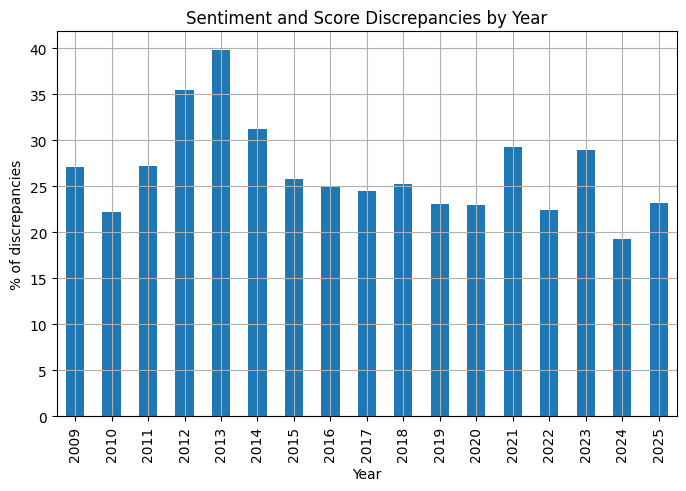

In [ ]:
# Calculate the number of mismatches between BERT sentiment and Star sentiment by year
diff_years = df[df['Match'] == False].groupby('Year').size()

# Calculate the total number of entries by year
total_years = df.groupby('Year').size()

# Calculate the percentage of mismatches per year (fill missing values with 0)
diff_part = (diff_years / total_years * 100).fillna(0)

# Plot the percentage of sentiment mismatches over the years
diff_part.plot(kind='bar', figsize=(8, 5), title='Sentiment and Score Discrepancies by Year')
plt.ylabel('% of discrepancies')
plt.grid(True)
plt.show()


In [ ]:
# Group by university name and calculate the percentage of False values (i.e., discrepancies)
discrepancies = df.groupby('University Name')['Match'].apply(lambda x: (x == False).mean() * 100)

# Sort the discrepancies in descending order
discrepancies = discrepancies.sort_values(ascending=False)

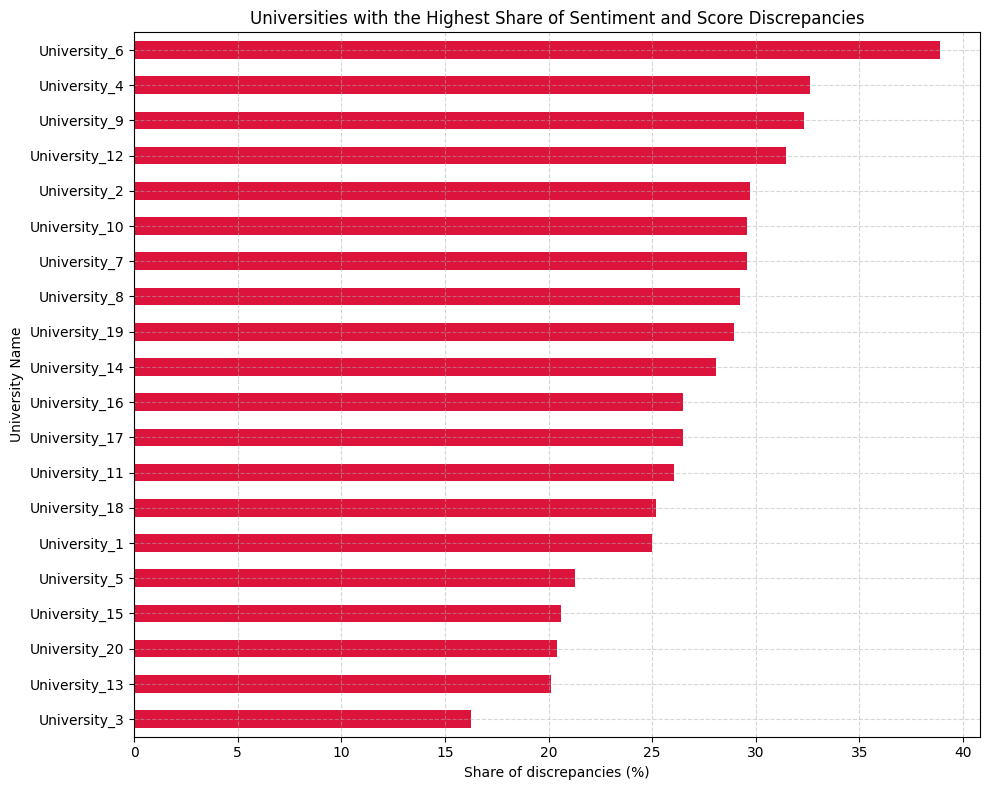

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
discrepancies.head(20).plot(kind='barh', color='crimson')  # Top 20 universities
plt.xlabel('Share of discrepancies (%)')
plt.title('Universities with the Highest Share of Sentiment and Score Discrepancies')
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

For further analysis, we will use only those reviews where the star rating and sentiment matched — this helps reduce errors.
• The loss of some reviews (~27%) did not have a critical impact: the analysis showed an even distribution of these reviews across years and universities.

We will determine the average sentiment of universities based on the BERT sentiment of individual reviews.
- Filtered reviews where the star rating and BERT sentiment matched, to reduce errors in the analysis.

- Mapped BERT sentiment categories to numerical values: negative = -1, neutral = 0, positive = 1. This allowed us to work with sentiment as a numeric score.

- Calculated the average sentiment score for each university by grouping reviews by university name and computing the mean of the numerical sentiment values.

- Classified the average sentiment scores into categories — positive, neutral, or negative — using defined thresholds (>= 0.5 as positive, <= -0.5 as negative, otherwise neutral).

In [ ]:
df_filtered = df[df['Match']]
df_filtered['University Name'].value_counts()

,count
University Name,
University_3,561
University_1,537
University_2,499
University_5,344
University_4,314
University_7,245
University_6,239
University_8,230
University_9,178


In [ ]:
# Calculate the normalized (proportion) distribution of BERT sentiment categories for each university
df_filtered.groupby('University Name')['Sentiment_Category_BERT'].value_counts(normalize=True)

University Name  Sentiment_Category_BERT
University_1     negative                   0.547486
                 positive                   0.448790
                 neutral                    0.003724
University_10    negative                   0.517045
                 positive                   0.471591
                 neutral                    0.011364
University_11    positive                   0.601156
                 negative                   0.387283
                 neutral                    0.011561
University_12    positive                   0.574324
                 negative                   0.412162
                 neutral                    0.013514
University_13    positive                   0.836735
                 negative                   0.163265
University_14    positive                   0.640625
                 negative                   0.335938
                 neutral                    0.023438
University_15    positive                   0.687023
                 negative                   0.312977
University_16    positive                   0.693694
                 negative                   0.306306
University_17    negative                   0.490000
                 positive                   0.480000
                 neutral                    0.030000
University_18    positive                   0.695652
                 negative                   0.282609
                 neutral                    0.021739
University_19    positive                   0.526316
                 negative                   0.460526
                 neutral                    0.013158
University_2     negative                   0.561122
                 positive                   0.432866
                 neutral                    0.006012
University_20    positive                   0.707317
                 negative                   0.243902
                 neutral                    0.048780
University_21    positive                   0.752809
                 negative                   0.235955
                 neutral                    0.011236
University_3     positive                   0.812834
                 negative                   0.174688
                 neutral                    0.012478
University_4     positive                   0.503185
                 negative                   0.474522
                 neutral                    0.022293
University_5     positive                   0.610465
                 negative                   0.386628
                 neutral                    0.002907
University_6     positive                   0.518828
                 negative                   0.468619
                 neutral                    0.012552
University_7     positive                   0.538776
                 negative                   0.453061
                 neutral                    0.008163
University_8     positive                   0.613043
                 negative                   0.382609
                 neutral                    0.004348
University_9     negative                   0.500000
                 positive                   0.494382
                 neutral                    0.005618
Name: proportion, dtype: float64

In [ ]:
# Map sentiment categories to numerical values: negative = -1, neutral = 0, positive = 1
mapping = {'negative': -1, 'neutral': 0, 'positive': 1}
df_filtered['Sentiment_Score'] = df_filtered['Sentiment_Category_BERT'].map(mapping)

/tmp/ipython-input-2136668389.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Sentiment_Score'] = df_filtered['Sentiment_Category_BERT'].map(mapping)


In [ ]:
df_filtered.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match,Sentiment_Score
0,University_1,716,2.97,2024-10-14,2.0,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,2,negative,negative,True,-1
1,University_1,716,2.97,2024-09-23,4.0,"Хороший преподавательский состав, размеренное ...",2024-09-23,2024,4,positive,positive,True,1
2,University_1,716,2.97,2023-02-02,1.0,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,1,negative,negative,True,-1
3,University_1,716,2.97,2023-01-23,1.0,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,1,negative,negative,True,-1
4,University_1,716,2.97,2022-09-16,1.0,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,1,negative,negative,True,-1


In [ ]:
# Calculate the average sentiment score for each university and reset the index
df_summary = df_filtered.groupby('University Name')['Sentiment_Score'].mean().reset_index()

# Rename the column to 'Average_Sentiment'
df_summary.rename(columns={'Sentiment_Score': 'Average_Sentiment'}, inplace=True)
df_summary

,University Name,Average_Sentiment
0,University_1,-0.098696
1,University_10,-0.045455
2,University_11,0.213873
3,University_12,0.162162
4,University_13,0.673469
5,University_14,0.304688
6,University_15,0.374046
7,University_16,0.387387
8,University_17,-0.010000
9,University_18,0.413043


In [ ]:
# Define a function to classify sentiment scores into categories:
# scores >= 0.5 as 'positive', <= -0.5 as 'negative', otherwise 'neutral'
# Apply this function to the 'Average_Sentiment' column to create a new categorical column
def classify(value):
    if value >= 0.5:
        return 'positive'
    elif value <= -0.5:
        return 'negative'
    else:
        return 'neutral'

df_summary['Sentiment_Category'] = df_summary['Average_Sentiment'].apply(classify)

In [ ]:
df_summary = df_summary.sort_values(by='Average_Sentiment', ascending=False).reset_index()
df_summary

,index,University Name,Average_Sentiment,Sentiment_Category
0,4,University_13,0.673469,positive
1,14,University_3,0.638146,positive
2,13,University_21,0.516854,positive
3,12,University_20,0.463415,neutral
4,9,University_18,0.413043,neutral
5,7,University_16,0.387387,neutral
6,6,University_15,0.374046,neutral
7,5,University_14,0.304688,neutral
8,19,University_8,0.230435,neutral
9,16,University_5,0.223837,neutral


Let’s create a heatmap to visualize the sentiment dynamics over the years.



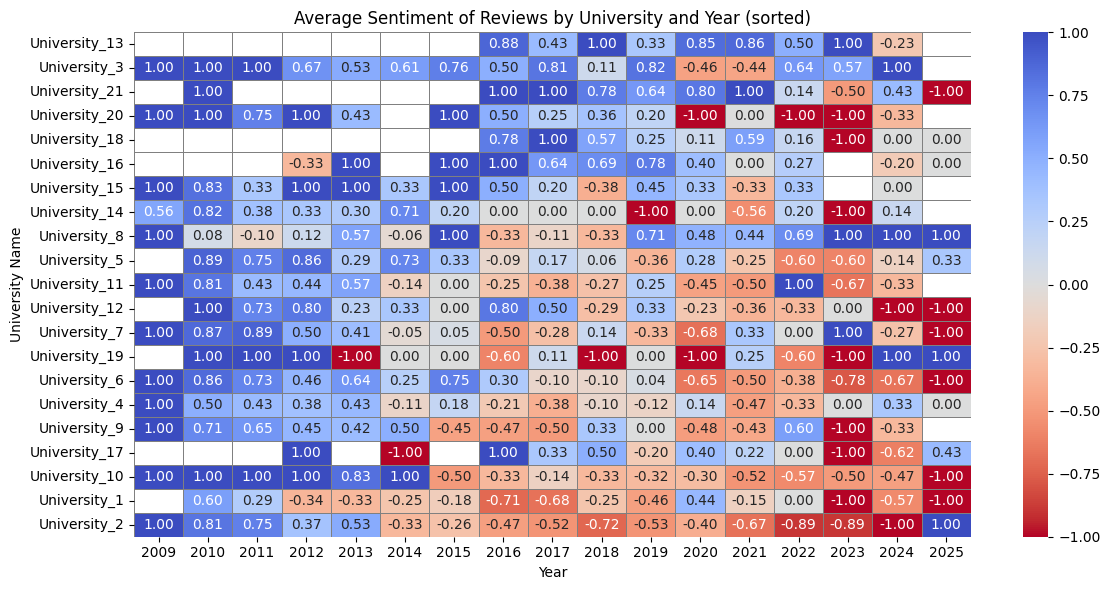

In [ ]:

# 1. Calculate the average sentiment score for each university
mean_sentiment = df_filtered.groupby('University Name')['Sentiment_Score'].mean()

# 2. Sort universities by average sentiment score (from most positive)
sorted_universities = mean_sentiment.sort_values(ascending=False).index

# 3. Prepare the data table for the heatmap, respecting the sorted university order
heatmap_data = df_filtered.groupby(['University Name', 'Year'])['Sentiment_Score'].mean().unstack()
heatmap_data = heatmap_data.loc[sorted_universities]  # apply sorting order

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap='coolwarm_r',
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Average Sentiment of Reviews by University and Year (sorted)')
plt.xlabel('Year')
plt.ylabel('University Name')

plt.tight_layout()
plt.show()

Using the heatmap, we can see that before 2014–2015, most universities had positive sentiment, but after that period, a decline in sentiment is observed.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving df_mismatch.csv to df_mismatch (1).csv


In [ ]:
df_mismatch.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match
8,University_1,716,2.97,2021-12-09,2.0,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,3,neutral,negative,False
11,University_1,716,2.97,2021-09-29,3.0,"Всем добрый день!Хороший университет,но почему...",2021-09-29,2021,4,positive,neutral,False
12,University_1,716,2.97,2021-08-25,1.0,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,3,neutral,negative,False
16,University_1,716,2.97,2020-06-01,4.0,нормальный университет все прошло хорошо.Кто х...,2020-06-01,2020,1,negative,positive,False
19,University_1,716,2.97,2020-04-07,5.0,"Читая ваши отзывы про другие кафедры, такое чу...",2020-04-07,2020,1,negative,positive,False


In [ ]:
df_mismatch['Manual_Category'] = ""
df_mismatch.head()

/tmp/ipython-input-3824066021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mismatch['Manual_Category'] = ""


,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match,Manual_Category
8,University_1,716,2.97,2021-12-09,2.0,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,3,neutral,negative,False,
11,University_1,716,2.97,2021-09-29,3.0,"Всем добрый день!Хороший университет,но почему...",2021-09-29,2021,4,positive,neutral,False,
12,University_1,716,2.97,2021-08-25,1.0,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,3,neutral,negative,False,
16,University_1,716,2.97,2020-06-01,4.0,нормальный университет все прошло хорошо.Кто х...,2020-06-01,2020,1,negative,positive,False,
19,University_1,716,2.97,2020-04-07,5.0,"Читая ваши отзывы про другие кафедры, такое чу...",2020-04-07,2020,1,negative,positive,False,


In [ ]:
df_mismatch.to_excel('df_mismatch_for_labeling.xlsx', index=False)